In [3]:
import math
import random
from itertools import combinations
from dataclasses import dataclass, field
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

IITR_BLUE   = "#1f497d"
IITR_ORANGE = "#df802a"
BREAKER_RED = "#cc2222"
THREAT_GOLD = "#e0b020"

plt.rcParams["figure.dpi"] = 110

In [4]:
def edge(u, v):
    """Canonical undirected edge as a frozenset."""
    return frozenset({u, v})

def maker_degree(v, M):
    return sum(1 for e in M if v in e)

def neighbours(v, edges):
    return {u for e in edges if v in e for u in e if u != v}

def threats(e, M):
    """T_e = {{b1,b2} : b1 in N_M(a1), b2 in N_M(a2)} \\ {e}.
    Each threat, combined with e, closes a C_4 using existing Maker edges.
    """
    a1, a2 = tuple(e)
    N1, N2 = neighbours(a1, M), neighbours(a2, M)
    out = set()
    for b1 in N1:
        for b2 in N2:
            if b1 != b2:
                t = edge(b1, b2)
                if t != e:
                    out.add(t)
    return out

def contains_c4(M):
    """True iff M contains a 4-cycle (no chords required)."""
    adj = {}
    for e in M:
        u, v = tuple(e)
        adj.setdefault(u, set()).add(v)
        adj.setdefault(v, set()).add(u)
    nodes = list(adj.keys())
    for u, v in combinations(nodes, 2):
        common = adj[u] & adj[v]
        if len(common) >= 2:
            return True
    return False

In [5]:
def random_breaker(free, q, rng):
    pool = list(free)
    rng.shuffle(pool)
    return set(pool[:q])

def adversarial_breaker(free, M, q, must_block=None):
    """Greedy: prioritise edges in `must_block`, then edges with highest |T_e|."""
    picks = []
    if must_block:
        for t in must_block:
            if t in free and t not in picks:
                picks.append(t)
                if len(picks) == q:
                    return set(picks)
    scored = sorted(
        (e for e in free if e not in picks),
        key=lambda e: -len(threats(e, M))
    )
    for e in scored:
        picks.append(e)
        if len(picks) == q:
            break
    return set(picks)

In [6]:
@dataclass
class GameLog:
    n: int
    d: int
    q: int
    M: set = field(default_factory=set)
    B: set = field(default_factory=set)
    free: set = field(default_factory=set)
    history: list = field(default_factory=list)  # (round, who, edge, phase)
    X_at_end_of_phase1: set = field(default_factory=set)
    e_star: Optional[frozenset] = None
    threats_e_star: set = field(default_factory=set)
    closing_edge: Optional[frozenset] = None
    cycle: Optional[list] = None
    winner: str = "undecided"

def play_sowa_srivastav(n, q, d, breaker="adversarial", seed=0, verbose=False):
    """Run the full Sowa–Srivastav C_4 strategy and return a GameLog.

    Parameters
    ----------
    n         : number of vertices
    q         : Breaker's bias (edges per round)
    d         : target Maker-degree (= ceil(delta * n^(1/3)))
    breaker   : 'random' or 'adversarial'
    seed      : RNG seed for tie-breaking / random Breaker
    verbose   : print a round-by-round trace
    """
    rng = random.Random(seed)
    V = list(range(n))
    log = GameLog(n=n, d=d, q=q)
    log.free = {edge(u, v) for u, v in combinations(V, 2)}

    def breaker_move(must_block=None):
        if breaker == "random":
            return random_breaker(log.free, q, rng)
        return adversarial_breaker(log.free, log.M, q, must_block=must_block)

    # -------- Phase 1 --------
    rd = 0
    while True:
        candidates = [
            e for e in log.free
            if max(maker_degree(u, log.M) for u in e) < d
        ]
        if not candidates:
            break
        rng.shuffle(candidates)
        e = min(candidates,
                key=lambda e: sum(maker_degree(u, log.M) for u in e))
        rd += 1
        log.free.discard(e)
        log.M.add(e)
        log.history.append((rd, "M", e, "P1"))
        if verbose:
            print(f"Rd {rd:2d} | Maker plays {set(e)}  (P1)")
        # Breaker
        for b in breaker_move():
            log.free.discard(b)
            log.B.add(b)
            log.history.append((rd, "B", b, "P1"))
            if verbose:
                print(f"       Breaker plays {set(b)}")

    log.X_at_end_of_phase1 = {v for v in V if maker_degree(v, log.M) >= d}
    if verbose:
        print(f"\nPhase 1 done in {rd} Maker rounds.")
        print(f"X = {sorted(log.X_at_end_of_phase1)}, |X| = {len(log.X_at_end_of_phase1)}")

    # -------- Phase 2: find active dangerous --------
    X = log.X_at_end_of_phase1
    e_star = None
    T_star = None
    candidates = [e for e in log.free if all(u in X for u in e)]
    candidates.sort(key=lambda e: -len(threats(e, log.M) - log.B))
    for e in candidates:
        T_e = threats(e, log.M)
        if len(T_e - log.B) > q:
            e_star = e
            T_star = T_e
            break
    if e_star is None:
        log.winner = "Breaker (no active dangerous edge)"
        if verbose:
            print("No active dangerous edge — Breaker wins or strategy fails for this n,q.")
        return log
    log.e_star = e_star
    log.threats_e_star = T_star
    rd += 1
    log.free.discard(e_star)
    log.M.add(e_star)
    log.history.append((rd, "M", e_star, "P2"))
    if verbose:
        free_threats = T_star - log.B
        print(f"\nRd {rd:2d} | Maker plays e* = {set(e_star)}  (P2)")
        print(f"       |T_e*| = {len(T_star)}, free threats = {len(free_threats)} > q={q}")
    # Breaker
    for b in breaker_move(must_block=T_star - log.B):
        log.free.discard(b)
        log.B.add(b)
        log.history.append((rd, "B", b, "P2"))
        if verbose:
            print(f"       Breaker plays {set(b)}")

    # -------- Phase 3: close --------
    survivors = T_star - log.B
    if not survivors:
        log.winner = "Breaker (Lemma 7(vi) violated — small n?)"
        return log
    closer = next(iter(survivors))
    rd += 1
    log.free.discard(closer)
    log.M.add(closer)
    log.closing_edge = closer
    log.history.append((rd, "M", closer, "P3"))
    # Reconstruct cycle order: a1 - b1 - b2 - a2 - a1
    a1, a2 = tuple(e_star)
    b1, b2 = tuple(closer)
    if b1 in neighbours(a1, log.M) and b2 in neighbours(a2, log.M):
        log.cycle = [a1, b1, b2, a2]
    else:
        log.cycle = [a1, b2, b1, a2]
    log.winner = "Maker"
    if verbose:
        print(f"\nRd {rd:2d} | Maker plays closer {set(closer)}  (P3)")
        print(f"       C_4: {' → '.join(map(str, log.cycle + [log.cycle[0]]))}")
        print(f"\nWinner: Maker ✓")
    return log

In [7]:
def vertex_positions(n, radius=1.0):
    return {i: (radius*np.cos(2*np.pi*i/n + np.pi/2),
                radius*np.sin(2*np.pi*i/n + np.pi/2))
            for i in range(n)}

def draw_state(log, ax=None, title=None,
               show_threats=False, highlight_cycle=False,
               highlight_e_star=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    pos = vertex_positions(log.n)

    # C_4 halo (behind everything)
    if highlight_cycle and log.cycle:
        cyc = log.cycle + [log.cycle[0]]
        for u, v in zip(cyc, cyc[1:]):
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color=IITR_ORANGE, linewidth=14, alpha=0.25, zorder=0,
                    solid_capstyle="round")

    # Live threats (dotted gold)
    if show_threats and log.e_star is not None:
        free_threats = log.threats_e_star - log.B
        for t in free_threats:
            u, v = tuple(t)
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color=THREAT_GOLD, linewidth=2.2, linestyle=":", zorder=1)

    # Breaker edges (dashed red)
    for e in log.B:
        u, v = tuple(e)
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color=BREAKER_RED, linewidth=1.4, linestyle="--",
                alpha=0.85, zorder=2)

    # Maker edges (solid blue, or orange for closer/e*)
    closing = {log.e_star, log.closing_edge} - {None}
    for e in log.M:
        u, v = tuple(e)
        if highlight_e_star and e in closing:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color=IITR_ORANGE, linewidth=3.2, zorder=3)
        else:
            ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                    color=IITR_BLUE, linewidth=2.2, zorder=3)

    # Vertices
    for i, (x, y) in pos.items():
        ax.scatter([x], [y], s=300, color=IITR_BLUE, zorder=4)
        ax.text(x*1.18, y*1.18, str(i), ha="center", va="center",
                fontsize=12, fontweight="bold", color="black")

    ax.set_aspect("equal")
    ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=13, color=IITR_BLUE, fontweight="bold")
    return ax

def draw_three_phases(log, figsize=(16, 5.5)):
    """Side-by-side panels showing the state after each phase."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    # Snapshot after Phase 1: build a synthetic log with only P1 edges
    p1_log = GameLog(n=log.n, d=log.d, q=log.q)
    for (rd, who, e, phase) in log.history:
        if phase == "P1":
            (p1_log.M if who == "M" else p1_log.B).add(e)
    draw_state(p1_log, ax=axes[0], title="After Phase 1 (d-degree)")

    # After Phase 2 (Maker plays e*)
    p2_log = GameLog(n=log.n, d=log.d, q=log.q)
    for (rd, who, e, phase) in log.history:
        if phase in ("P1", "P2"):
            (p2_log.M if who == "M" else p2_log.B).add(e)
    p2_log.e_star = log.e_star
    p2_log.threats_e_star = log.threats_e_star
    draw_state(p2_log, ax=axes[1], title="After Phase 2 (play $e^*$)",
               show_threats=True, highlight_e_star=True)

    # After Phase 3 (cycle closed)
    draw_state(log, ax=axes[2], title="After Phase 3 ($C_4$ closed)",
               highlight_cycle=True, highlight_e_star=True)
    plt.tight_layout()
    return fig

In [8]:
#DEMO for K6
log = play_sowa_srivastav(n=6, q=1, d=2, breaker="adversarial", seed=0, verbose=True)

Rd  1 | Maker plays {1, 4}  (P1)
       Breaker plays {3, 4}
Rd  2 | Maker plays {2, 3}  (P1)
       Breaker plays {1, 2}
Rd  3 | Maker plays {0, 5}  (P1)
       Breaker plays {0, 3}
Rd  4 | Maker plays {2, 5}  (P1)
       Breaker plays {4, 5}
Rd  5 | Maker plays {0, 4}  (P1)
       Breaker plays {2, 4}
Rd  6 | Maker plays {1, 3}  (P1)
       Breaker plays {1, 5}

Phase 1 done in 6 Maker rounds.
X = [0, 1, 2, 3, 4, 5], |X| = 6

Rd  7 | Maker plays e* = {3, 5}  (P2)
       |T_e*| = 3, free threats = 2 > q=1
       Breaker plays {0, 1}

Rd  8 | Maker plays closer {0, 2}  (P3)
       C_4: 3 → 2 → 0 → 5 → 3

Winner: Maker ✓


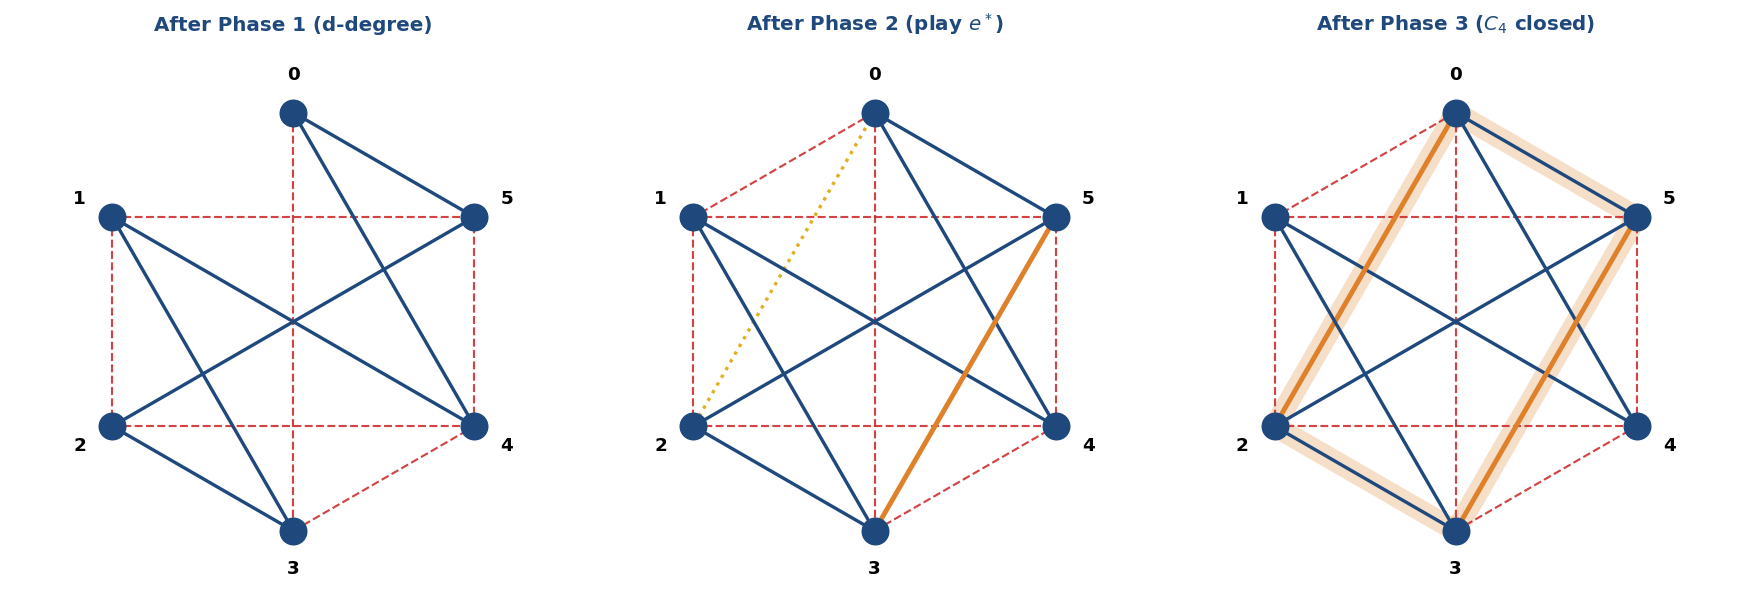

In [9]:
fig = draw_three_phases(log)
plt.show()

In [10]:
from ipywidgets import interact, IntSlider, Dropdown, IntText, Checkbox
from IPython.display import display, Markdown

def _show(n, q, d, breaker, seed, verbose):
    log = play_sowa_srivastav(n=n, q=q, d=d, breaker=breaker,
                              seed=seed, verbose=verbose)
    c = q / n**(2/3)
    delta = d / n**(1/3)
    beta = len(log.X_at_end_of_phase1) / n
    md = (f"**Result:** {log.winner}\u2003 "
          f"**Implied parameters:** "
          f"$c \\approx {c:.3f}$, "
          f"$\\delta \\approx {delta:.3f}$, "
          f"$\\beta \\approx {beta:.3f}$")
    display(Markdown(md))
    fig = draw_three_phases(log)
    plt.show()

interact(
    _show,
    n=IntSlider(min=4, max=14, step=1, value=6, description="n"),
    q=IntSlider(min=1, max=6, step=1, value=1, description="q"),
    d=IntSlider(min=2, max=5, step=1, value=2, description="d"),
    breaker=Dropdown(options=["adversarial", "random"], value="adversarial",
                     description="Breaker"),
    seed=IntText(value=7, description="Seed"),
    verbose=Checkbox(value=False, description="Print trace"),
);

interactive(children=(IntSlider(value=6, description='n', max=14, min=4), IntSlider(value=1, description='q', …